In [1]:
# Create a Machine Learning that can predict profit based on sales and other features, (Regression Task)
# Predict Customer Type based on transaction data, (Classification Task)
'''
1. Import necessary libraries
2. Load the dataset and Explore (EDA) the data
3. Preprocess the data (handle missing values, encode categorical variables, feature scaling)
4. Split the dataset into training and testing sets
5. Train a regression model to predict profit based on sales and other features
6. Evaluate the regression model using appropriate metrics (e.g., RMSE, R-squared)
7. Train a classification model to predict customer type based on transaction data
8. Evaluate the classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score)
9. Visualize the results and interpret the findings 


'''

'\n1. Import necessary libraries\n2. Load the dataset and Explore (EDA) the data\n3. Preprocess the data (handle missing values, encode categorical variables, feature scaling)\n4. Split the dataset into training and testing sets\n5. Train a regression model to predict profit based on sales and other features\n6. Evaluate the regression model using appropriate metrics (e.g., RMSE, R-squared)\n7. Train a classification model to predict customer type based on transaction data\n8. Evaluate the classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score)\n9. Visualize the results and interpret the findings \n\n\n'

In [4]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import sci-kit for machine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ignore Warnings
# import warnings
# warnings.filterwarnings('ignore')



In [5]:
# Step 2: Load the dataset and Explore (EDA) the data
# Load the dataset
df = pd.read_csv('ecommerce_bigdata.csv')  # Replace 'your_dataset.csv' with

In [6]:
# Display the first few rows of the dataset
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [7]:
# Preprocess the data (handle missing values, encode categorical variables, feature scaling)

# Check for empty values in the dataset
# Check for Duplicate rows
# Wrong format of data in the dataset
# Wrong data type in the dataset

#df = df.dropna()  # Handle missing values

# Check for missing values
df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [8]:
# Summary statistics of the dataset
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


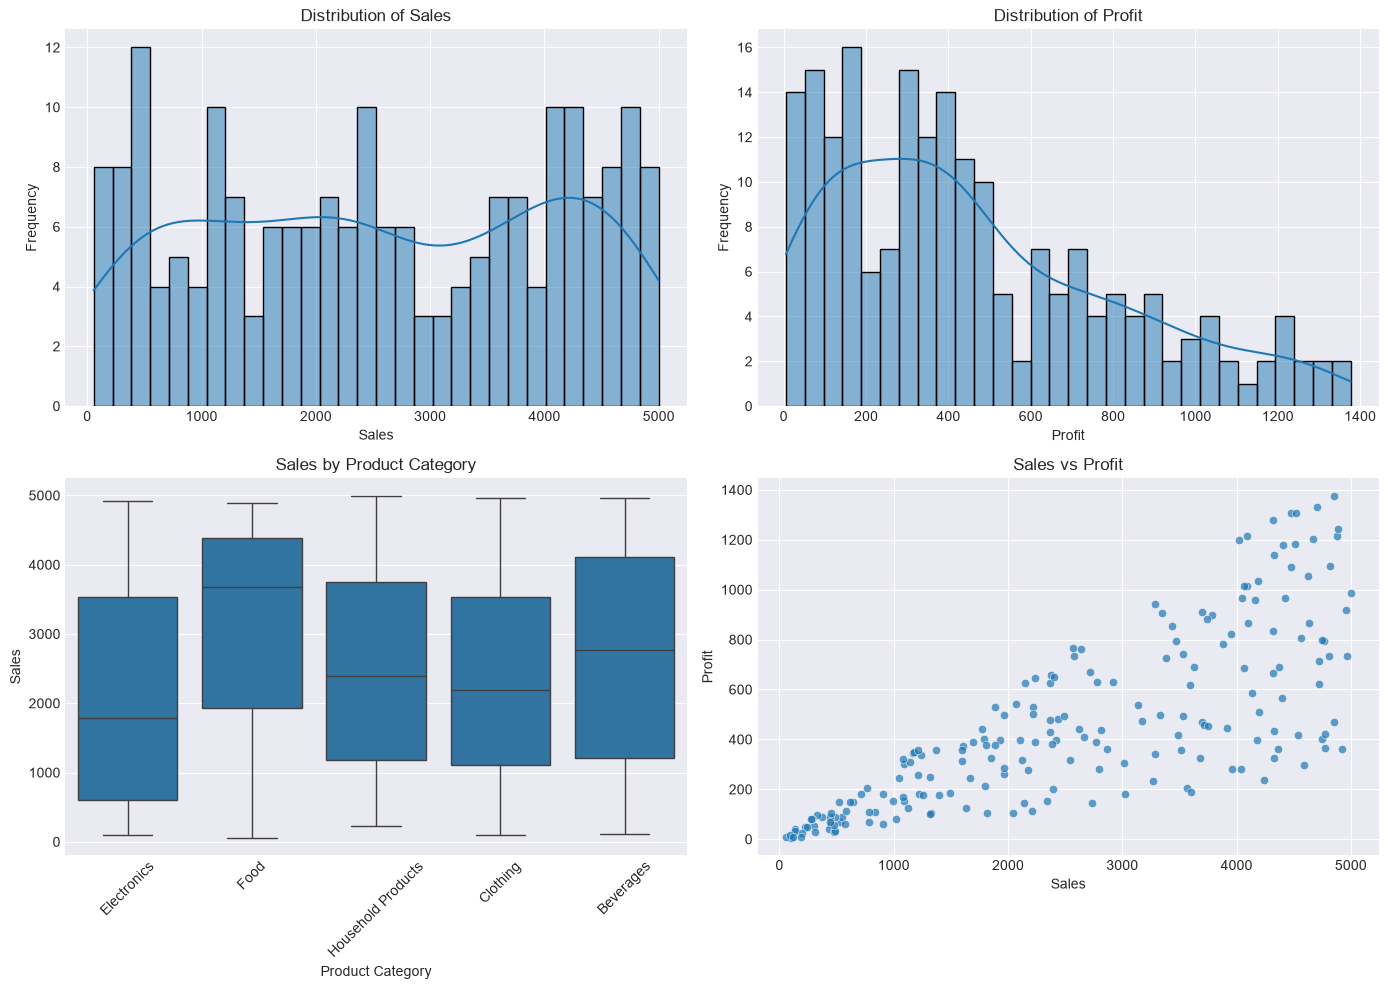

In [ ]:
# Data Visualization
# Setup the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# 1 Plot Distribution of Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sales')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Frequency')

# 2 Plot Distribution of Profit
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Profit')
axes[0, 1].set_xlabel('Profit')
axes[0, 1].set_ylabel('Frequency')

# Exercises 2
# Plot sales by product category (Boxplot) 

# Plot the relationship between Sales and Profit (Scatter plot)

# 3 Plot sales by product category (Boxplot)
sns.boxplot(data=df, x='ProductCategory', y='Sales', ax=axes[1, 0])
axes[1, 0].set_title('Sales by Product Category')
axes[1, 0].set_xlabel('Product Category')
axes[1, 0].set_ylabel('Sales')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4 Plot the relationship between Sales and Profit (Scatter plot)
sns.scatterplot(data=df, x='Sales', y='Profit', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Sales vs Profit')
axes[1, 1].set_xlabel('Sales')
axes[1, 1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

In [10]:
# Step 4: 3. Feature Engineering: Selecting and creating relevant features that will help the model learn better.
# Create a copy of the original dataframe to avoid modifying it directly
df_processed = df.copy()


# Convert Date to datetime format and extract relevant features (e.g., year, month, day)

df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday